# Going Deeper into a regression model with a project

I hope you remember the Deep learning life cycle.

First step is loading the data.

## Loading the data

I'll be using the `Medical cost personal` dataset from the [kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance). 

This dataset contains personal health insurance costs for 1338 individuals. The columns are as follows:

- age: age of primary beneficiary
- sex: insurance contractor gender, female, male
- bmi: Body mass index, providing an understanding of body fatness
- children: Number of children covered by health insurance / Number of dependents
- smoker: Smoking, yes or no
- region: the beneficiary's geographic information, Southeast, Southwest, Northeast, Northwest
- charges: Individual medical costs billed by health insurance

A small and nice data set to clean and do some deep learning experiments.

You can download the dataset from kaggle or you can directly load from github without any downloading.

> Pandas can load raw data from links. Here's the [link](https://raw.githubusercontent.com/RishatTalukder/Deep_Learning_With_Tensorflow/refs/heads/main/2_regression/insurance.csv)

In [1]:
import pandas as pd

data = pd.read_csv(
    "https://raw.githubusercontent.com/RishatTalukder/Deep_Learning_With_Tensorflow/refs/heads/main/2_regression/insurance.csv"
)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


See? nice right?

We can now use this dataset. 

So, time for the second step. 

##  Data Analysis

First let's check the information of the dataset.

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


We have a total of 1338 rows and 7 columns and no missing values.

That makes our work simpler and I'm not thinking of going too deep, I'm going to keep it direct.

There's might be some categorical features in this dataset. Let's check that.

In [3]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Only `age`, `bmi`, `children` and `charges` are numerical features. 

So, the rest can be categorical.  Let's see..

In [4]:
data.smoker.unique()

<ArrowStringArray>
['yes', 'no']
Length: 2, dtype: str

In [5]:
data.sex.unique()

<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

In [6]:
data.region.unique()

<ArrowStringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

Yeah, looks like `smoker`, `sex` and `region` features are categorical features.

There's another feature that can be categorical even if it is numerical.

In [7]:
data.children.unique()

array([0, 1, 3, 2, 5, 4])

Yeap, as you can see the children column can be categorical. But as this features represents the number of children, I'm going to keep it numerical.

Now, we have to transform the categorical feature to numetical feature. Because these feature are in string format.

So, now we can `one hot encode` the categorical features.

> You can leanr `One-hot encoding` from [here](https://youtu.be/FDLZNDyW3T4)

A little summery of `One-hot encoding`:

- One-hot encoding is a technique used to convert categorical variables into numerical variables.

- It creates a new column for each unique category in the categorical variable.

- Each cell in the new column is either 0 or 1, indicating whether the corresponding category is present in the original categorical variable.

- The value 1 indicates the presence of the category, while 0 indicates its absence.

- Let's say we have a categorical column like this:

| sex |
| --- |
| male |
| male |
| female |
| female |
| male |

- we takes all the unique values of the column and create a new column for each unique value.

| sex_male | sex_female |
| --- | --- |
| 1 | 0 |
| 1 | 0 |
| 0 | 1 |
| 0 | 1 |
| 1 | 0 |

- Each of these columns have a value of 1 or 0, indicating whether the corresponding category is present in the original categorical variable.

- Occasionally, we can drop one of these columns, because in this case if a row has 1 in the `sex_male` column, it means that the row has the `male` category, there is no chance that the row can have the `female` category. So, we can drop the `sex_female` column. This logic can be applied to any number of categories and we can drop a column and still the ammount of information will stay the same.


So, how do we  do this?

We can Either use a `pandas dataframe method` or a `sklearn preprocessing class` to do this.

I prefer to use both, which ever is convenient for me.

I show you both.

### One hot encoding using `get_dummies()`

In [8]:
pd.get_dummies(
    data,
    columns=["sex", "smoker", "region"],
    drop_first=True,
)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,True,False,True,False,False
1334,18,31.920,0,2205.98080,False,False,False,False,False
1335,18,36.850,0,1629.83350,False,False,False,True,False
1336,21,25.800,0,2007.94500,False,False,False,False,True


`pd.get_dummies` is a function that takes a pandas dataframe as input and returns a new dataframe with one-hot encoded columns for the specified categorical columns.

You can specify which columns to one-hot encode using the `columns` parameter or if you dont it'll one-hot encode all column with `object`, `string` or `category` dtype.

If you want to drop one of the one-hot encoded columns, you can use the `drop_first` parameter.

We can do the same using `sklearn` `OneHotEncoder` class.

In [9]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    drop="first",
)
encoder.set_output(transform="pandas")
encoder.fit_transform(data[["sex", "smoker", "region"]])

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
1333,1.0,0.0,1.0,0.0,0.0
1334,0.0,0.0,0.0,0.0,0.0
1335,0.0,0.0,0.0,1.0,0.0
1336,0.0,0.0,0.0,0.0,1.0


Here I'm using `OneHotEncoder` class from `sklearn` to do the same thing.

Inside, I've set `sparse_output=False` because I want the output to be a pandas dataframe and not a sparse matrix.

And I've set `drop="first"` because I want to drop one of the one-hot encoded columns.

I've set `transform="pandas"` in using the `set_output` method because I want the output to be a pandas dataframe.

And after that I'm using `fit_transform` method to fit the encoder to the data and transform the data.

And we have the one-hot encoded dataframe.

I'll set up a pipeline for this process in this article later. But for now let's stick with `get_dummies` method.

In [10]:
data = pd.get_dummies(
    data,
    columns=["sex", "smoker", "region"],
    drop_first=True,
)

In [11]:
data.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


Nice.

Now, we can just train a model. But first we have to split.

## Splitting the data

In this data set the target is to predict the `charges` column which represents the individual medical costs billed by health insurance.

In [12]:
X = data.drop(
    columns=["charges"],
)

y = data["charges"]

Now  we split.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [14]:
X_train.shape

(1070, 8)

And we have our train and test sets.

One thing left to do.

## Building the model and training it

I'll make a very small model for the first try.

In [15]:
import tensorflow as tf
from keras import (
    layers,
    losses,
    metrics,
    models,
    optimizers,
)

2026-09-02 15:37:44.435576: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:


model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(10, activation="relu"),
    layers.Dense(5, activation="relu"),
    layers.Dense(1),
])

model.compile(
    optimizer=optimizers.Adam(),
    loss=losses.MeanAbsoluteError(),
    metrics=[metrics.RootMeanSquaredError()],
)

I0000 00:00:1788341879.544891   12726 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9552 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


This model will have 3 layers, the first one will have 10 nodes, the second one will have 5 nodes and the last one will have 1 node.

And I'm using `Adam` optimizer and `MeanAbsoluteError` loss function and `RootMeanSquaredError` metric to see if the models are overfitting or underfitting.

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

Let's see how our model performs.

In [18]:
model.fit(
    X_train,
    y_train,
    epochs=100
)

Epoch 1/100


2026-09-02 15:38:03.814769: I external/local_xla/xla/service/service.cc:163] XLA service 0x77f8c4006790 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-02 15:38:03.814783: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2026-09-02 15:38:03.990849: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-02 15:38:04.420435: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


 1/34 ━━━━━━━━━━━━━━━━━━━━ 1:24 3s/step - loss: 16697.7266 - root_mean_squared_error: 23484.3223

I0000 00:00:1788341885.920690   13237 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 13344.0449 - root_mean_squared_error: 17955.3398
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13341.7197 - root_mean_squared_error: 17953.5293 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13339.0830 - root_mean_squared_error: 17951.4473 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13335.9189 - root_mean_squared_error: 17948.9375 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13332.0898 - root_mean_squared_error: 17945.9395 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13327.3477 - root_mean_squared_error: 17942.1738 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13321.3623 - root_mean_squared_error: 17937.4824 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13313.7744 - root_mean_squared_error: 17931.4180 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13304.2324 - root_mean_squared_error: 17923.9258 
Epoch 10/100
34/34 ━━━━━━━━━━━━

Alright, no good. The loss is still pretty `High` and the RMSE shows that the model is predicting some pretty bad values.

But let's just evaluate it on the testing data first.

In [19]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 7491.6353 - root_mean_squared_error: 12483.1523


[7491.63525390625, 12483.15234375]

Doesn't seem so bad right. But If we see that mean and  median of the target variable we might  know how bad this model is.

In [20]:
y.mean(), y.median()

(np.float64(13270.422265141257), 9382.033)

The mean absolute error is the avgerage of the absolute difference between the predicted and actual values. 

So, on average the model is off by 7014 dollers whereas the median is 13270 dollars. This is bad.

And if you take the median it's even worse.

So, we need to improve the model.

How do we do that.

We can do:

- Make the model more complex
- Train for longer.
- Try different optimizers.

Let's start with making the model more complex.

### Making the model more complex

This time let's go for 3 hidden layers and 64, 32, 16 neurons respectively.

In [21]:
model2 = models.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ]
)

model2.compile(
    optimizer=optimizers.Adam(),
    loss=losses.MeanAbsoluteError(),
    metrics=[metrics.RootMeanSquaredError()],
)

model2.fit(
    X_train,
    y_train,
    epochs=100
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 13339.8438 - root_mean_squared_error: 17951.7363
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13309.0166 - root_mean_squared_error: 17927.2070 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13180.5576 - root_mean_squared_error: 17825.2891 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12678.2695 - root_mean_squared_error: 17430.3301
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11242.0811 - root_mean_squared_error: 16346.7217 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8759.0635 - root_mean_squared_error: 14297.3154  
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7454.9946 - root_mean_squared_error: 12492.3838  
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7394.9966 - root_mean_squared_error: 12332.7754 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7372.7007 - root_mean_squared_error: 12351.2119 
Epoch 10/100
34/34 ━━━

Well, now it looks better than before. I'm sure it will perform better with testing set too... 

But I want to see if it can get even better. I'll the fit  method again for 100 epochs and The model will continue training from where it left off.

In [22]:
model2.fit(
    X_train,
    y_train,
    epochs=100
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4026.5317 - root_mean_squared_error: 8482.2510 
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3929.5945 - root_mean_squared_error: 8291.8564 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3865.2478 - root_mean_squared_error: 8117.9902 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3880.7698 - root_mean_squared_error: 8034.4229 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3774.5281 - root_mean_squared_error: 7871.8335 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3721.5916 - root_mean_squared_error: 7765.6494 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3699.7976 - root_mean_squared_error: 7676.1201 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3669.6711 - root_mean_squared_error: 7604.1597 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3650.6406 - root_mean_squared_error: 7554.9932 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━

Yes, the loss did decrease. But not that much.

Let's evaluate.

In [23]:
model2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 2755.1304 - root_mean_squared_error: 6306.9321


[2755.13037109375, 6306.93212890625]

Very good!! If we compare it with the previous model it should be much better.

In [24]:
model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7491.6353 - root_mean_squared_error: 12483.1523 


[7491.63525390625, 12483.15234375]

We just halved the MAE and RMSE. NOICE!

One fun thing we can do is see how the model actually learned by observing the loss value for each epoch.

But the  problem is when we ran the  model again for 100 epochs the previous history was overwritten.

Now  worries, now we know that the second  model will perform better so letting it have another go wont hurt it.

In [25]:
model2 = models.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ]
)

model2.compile(
    optimizer=optimizers.Adam(),
    loss=losses.MeanAbsoluteError(),
    metrics=[metrics.RootMeanSquaredError()],
)

model2.fit(
    X_train,
    y_train,
    epochs=200
)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 13316.1611 - root_mean_squared_error: 17932.5195
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13230.1465 - root_mean_squared_error: 17863.4023 
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12964.4346 - root_mean_squared_error: 17653.3086 
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12230.8770 - root_mean_squared_error: 17093.4473 
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10614.3232 - root_mean_squared_error: 15849.3682 
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8414.6758 - root_mean_squared_error: 13953.8809  
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7411.2144 - root_mean_squared_error: 12512.3740 
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7365.7007 - root_mean_squared_error: 12371.2461 
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7338.7490 - root_mean_squared_error: 12359.1523 
Epoch 10/200
34/34 ━━━

Now, we can see how the loss has decreased.

In [26]:
model2.history.history

{'loss': [13316.1611328125,
  13230.146484375,
  12964.4345703125,
  12230.876953125,
  10614.3232421875,
  8414.67578125,
  7411.21435546875,
  7365.70068359375,
  7338.7490234375,
  7309.443359375,
  7281.6982421875,
  7252.701171875,
  7224.05712890625,
  7193.66748046875,
  7160.09423828125,
  7124.54931640625,
  7094.9111328125,
  7055.75048828125,
  7019.11572265625,
  6982.2236328125,
  6945.7763671875,
  6908.6640625,
  6867.45166015625,
  6826.474609375,
  6785.369140625,
  6751.2080078125,
  6720.98779296875,
  6682.05908203125,
  6662.36572265625,
  6654.9140625,
  6624.8759765625,
  6611.73095703125,
  6604.14501953125,
  6594.91650390625,
  6582.86572265625,
  6577.49462890625,
  6567.49267578125,
  6554.69140625,
  6551.26904296875,
  6543.8876953125,
  6534.42138671875,
  6523.22265625,
  6514.931640625,
  6504.54296875,
  6495.96533203125,
  6491.42724609375,
  6478.59765625,
  6468.60791015625,
  6456.19091796875,
  6447.66650390625,
  6437.68505859375,
  6426.91845703

Seeing the number wont help us much. Let's plot it.

<Axes: >

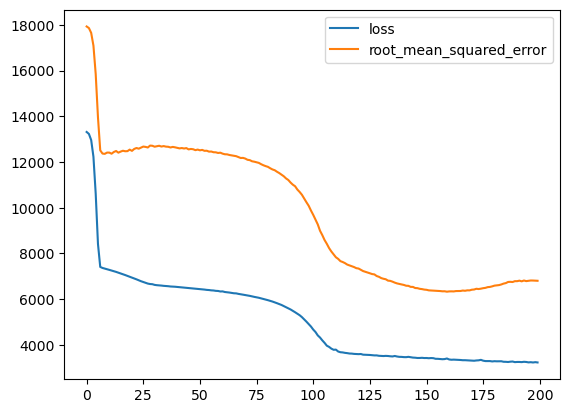

In [27]:
pd.DataFrame(model2.history.history).plot()

And If you take a look at the chart the loss(mae) and the RMSE is decreasing but the gap between the two is pretty wide.

> Remember the RMSE value flucutions.

This means the model is learning the training set but it is also giving wrong answers for outliers.

> Outliers are data points that are far away from the rest of the data points.

Our model should be able to handle outliers but in this case it is not.

To fix this what we can do is:

- Choose a different loss function(more robust)
- Remove the outliers.

Removing the outliers is not easy and can be very tedious. And we will go into talking about more robust loss functions later.

One thing I want to talk about before ending this is scaling the data.

## Scaling

It is proven that a neural network can be very  sensitive to data with different scales. Like a data set with values in meters, kgs, years. This can cause the netowrk to get stuck and produce bad results.

It is a best approach to set all the feature data to a common scale.

The default `scaling` method for neural networks is `minmax` scaling.

What does it do? It scales the data to a range between 0 and 1.

Formula is very simple:

$$
x_{scaled} = \frac{x - min(x)}{max(x) - min(x)}
$$

Another common scaling method is `standardization` scaling.

This method sets the mean to 0 and the standard deviation to 1 of a feature.

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

For now. let's use `minmax` scaling and see if the model performs better.

We can use `sklearn` `MinMaxScaler` class.

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.set_output(transform="pandas")
scaler.fit_transform(X)


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,0.021739,0.321227,0.0,0.0,1.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,1.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,1.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,1.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.695652,0.403820,0.6,1.0,0.0,1.0,0.0,0.0
1334,0.000000,0.429379,0.0,0.0,0.0,0.0,0.0,0.0
1335,0.000000,0.562012,0.0,0.0,0.0,0.0,1.0,0.0
1336,0.065217,0.264730,0.0,0.0,0.0,0.0,0.0,1.0


Works nicely right?

But the problem is we cannot tell the model to scale only `age`,  `bmi` and `children` columns.

It'll scale all the columns. Even though it's not a big issue but it is still not the best practice.

Best practice would be not set up a `column transformer` for scaling and for `one-hot encoding` at the same time.

We can do that with another class from  `sklearn` called `ColumnTransformer` class.

I want to show you the whole thing so let's load the data again.

In [32]:
import pandas as pd

data = pd.read_csv(
    "https://raw.githubusercontent.com/RishatTalukder/Deep_Learning_With_Tensorflow/refs/heads/main/2_regression/insurance.csv"
)
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Now we can use `ColumnTransformer` class.

In [36]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    [
        ("scaler", MinMaxScaler(), ["age", "bmi", "children"]),
        ("onehot", OneHotEncoder(drop="first", sparse_output=False), ["sex", "smoker", "region"]),
    ],
    
)

We now use the `ct` object to transform the data.

We can transform the whole dataset at once. But first we have to separate the features and the labels.

In [37]:
X = data.drop(
    columns=["charges"],
)

y = data["charges"]

And now we `fit_transform`.

In [39]:
ct.set_output(transform="pandas")
scaled_X = ct.fit_transform(X)
scaled_X

,scaler__age,scaler__bmi,scaler__children,onehot__sex_male,onehot__smoker_yes,onehot__region_northwest,onehot__region_southeast,onehot__region_southwest
0,0.021739,0.321227,0.0,0.0,1.0,0.0,0.0,1.0
1,0.000000,0.479150,0.2,1.0,0.0,0.0,1.0,0.0
2,0.217391,0.458434,0.6,1.0,0.0,0.0,1.0,0.0
3,0.326087,0.181464,0.0,1.0,0.0,1.0,0.0,0.0
4,0.304348,0.347592,0.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...
1333,0.695652,0.403820,0.6,1.0,0.0,1.0,0.0,0.0
1334,0.000000,0.429379,0.0,0.0,0.0,0.0,0.0,0.0
1335,0.000000,0.562012,0.0,0.0,0.0,0.0,1.0,0.0
1336,0.065217,0.264730,0.0,0.0,0.0,0.0,0.0,1.0


And we are done.

we can now split the normalized data and train the model and see if the model preforms any better or not.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X,
    y,
    test_size=0.2,
    random_state=42
)

Now, we can train the model.

I'll make some changes to the model. I'll increase the number of neuron count to `64, 32, 32, 1` for the hidden layers.

In [42]:
model3 = models.Sequential(
    [
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ]
)

model3.compile(
    optimizer=optimizers.Adam(),
    loss=losses.MeanAbsoluteError(),
    metrics=[metrics.RootMeanSquaredError()],
)

model3.fit(
    X_train,
    y_train,
    epochs=200
)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 13345.4990 - root_mean_squared_error: 17956.4922
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13340.2324 - root_mean_squared_error: 17952.1211 
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13306.7686 - root_mean_squared_error: 17924.0996 
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13166.2090 - root_mean_squared_error: 17806.1328 
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12754.9551 - root_mean_squared_error: 17463.8770 
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11836.9004 - root_mean_squared_error: 16704.6543 
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10315.7275 - root_mean_squared_error: 15396.2969
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8662.1260 - root_mean_squared_error: 13664.5830 
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7678.9849 - root_mean_squared_error: 12191.7871  
Epoch 10/200
34/34 ━━

<Axes: >

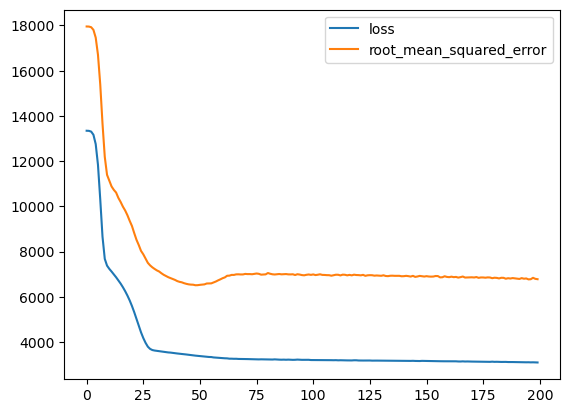

In [43]:
pd.DataFrame(model3.history.history).plot()

Well, the model is not better in the way i wanted it to be but still better than the previous one because the RMSE is not fluctuating like model2.

And if you take a look the model is actually learning faster than model2 and more stable.

Let's evaluate.

In [ ]:
model3.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 2770.6758 - root_mean_squared_error: 6423.6587


[2770.67578125, 6423.65869140625]

# Final Words

A model can be better in many ways. A better loss doesn't really mean the  model is better. Always remember a model with stable results is better than a model with less error but unstable results.